In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [3]:
import os
os.listdir(path)

['netflix_titles.csv']

In [ ]:
import pandas as pd
file_path = os.path.join(path,
"netflix_titles.csv")
df=pd.read_csv(file_path,
encoding="latin1")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.select_dtypes(include=['int64']).columns

Index(['release_year'], dtype='object')

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
print("Unique show_id:",
df['show_id'].nunique())

Unique show_id: 8807


# **Dataset Description:**

---

The Netflix dataset contains information about movies and TV shows available on Netflix. It includes details such as the unique show ID, content type, title, director, cast, country of origin, date added to Netflix, release year, content rating, duration, genre (listed_in), and a brief description. This dataset can be used to analyze Netflix's content library, identify trends in content production, distribution, and audience ratings.

**DATASET FINDINGS**

---

* The dataset contains 8,807 rows and 12 columns.
* Each records has a unique show_id, making it a suitable primary key.
* Some columns contain missing values that require data cleaning before analysis.
* There are no duplicate records found in the dataset.
* The dataset contains two type of content: Movies and TV shows.

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
director,2634
cast,825
country,831
date_added,10
rating,4
duration,3


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
print("Rows after removing duplicates:", df.shape)

Rows after removing duplicates: (8807, 12)


In [ ]:
df['director'] = df['director'].fillna('Unknown',inplace=True)
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

/tmp/ipykernel_1364/3327395106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'] = df['director'].fillna('Unknown',inplace=True)


In [ ]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,8797
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# **MISSING VALUE CLEANING EXPLAINATION**

---
The missing values in the director, cast, and country columns were replaced with "Unknown" because these are categorical variables, and filling them preserved the records without introducing incorrect information. The missing values in the rating and duration columns were replaced with the mode (most frequent value) since only a few values were missing. The rows with missing date_added values were removed because they were very few and would not significantly affect the analysis.

In [ ]:
# 1. Convert date_added to proper datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# 2. Standardize text columns - strip whitespace and fix casing where needed
df['type'] = df['type'].str.strip()
df['title'] = df['title'].str.strip()
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()
df['listed_in'] = df['listed_in'].str.strip()

# 3. Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Confirm changes
print(df.dtypes)
print(df[['date_added', 'type', 'country']].head())

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object
  date_added     type        country
0 2021-09-25    Movie  United States
1 2021-09-24  TV Show   South Africa
2 2021-09-24  TV Show        Unknown
3 2021-09-24  TV Show        Unknown
4 2021-09-24  TV Show          India


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


In [ ]:
df['rating'].value_counts(dropna=False)

,count
rating,
TV-MA,3209
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [ ]:
df.describe()

,date_added,release_year
count,8797,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.822191


In [ ]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8797,8797,8797,0,8797,8797,8797,8797,8797,8797
unique,8797,2,8797,0,7683,749,17,220,513,8765
top,s8807,Movie,Zubaan,NaN,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,NaN,825,2812,3209,1796,362,4


## Cleaning Summary

| Issue Found | Action Taken |
|-------------|--------------|
| Missing values | Filled missing values in director, cast, country, rating, and duration with "Unknown". Removed rows with missing date_added. |
| Duplicate records | Checked for duplicates and found *0* duplicate rows, so no records were removed. |
| Invalid entries | No invalid entries were identified during data validation. |
| Standardization | Converted date_added to datetime format, standardized column names to lowercase, and removed leading/trailing spaces from text columns. |

In [ ]:
print("Mean:", df['release_year'].mean())
print("Median:", df['release_year'].median())
print("Minimum:", df['release_year'].min())
print("Maximum:", df['release_year'].max())
print("Standard Deviation:", df['release_year'].std())

Mean: 2014.1834716380583
Median: 2017.0
Minimum: 1925
Maximum: 2021
Standard Deviation: 8.822190519562549


In [ ]:
content_type = df['type'].value_counts()
print(content_type)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [ ]:
# 1. Movies vs TV Shows distribution
type_distribution = df['type'].value_counts()
print("Movies vs TV Shows:\n", type_distribution)

Movies vs TV Shows:
 type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [ ]:
# 2. Content added by year
df['year_added'] = df['date_added'].dt.year
content_by_year = df['year_added'].value_counts().sort_index()
print("\nContent Added by Year:\n", content_by_year)


Content Added by Year:
 year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [ ]:
# 3. Top content-producing countries
top_countries = df['country'].value_counts().head(10)
print("\nTop 10 Content-Producing Countries:\n", top_countries)


Top 10 Content-Producing Countries:
 country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [ ]:
# 4. Most common ratings
top_ratings = df['rating'].value_counts().head(10)
print("\nMost Common Ratings:\n", top_ratings)


Most Common Ratings:
 rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


In [ ]:
# 5. Most common genres/categories
# Since listed_in has multiple genres per row separated by commas, we split them
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
print("\nMost Common Genres:\n", top_genres)


Most Common Genres:
 listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

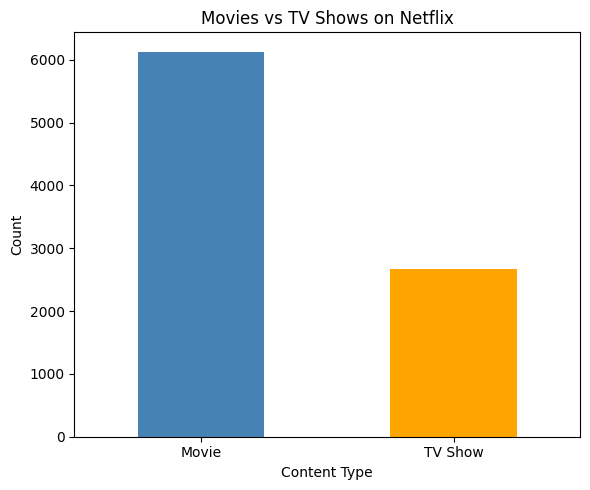

In [ ]:
plt.figure(figsize=(6,5))
type_distribution.plot(kind='bar', color=['steelblue','orange'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

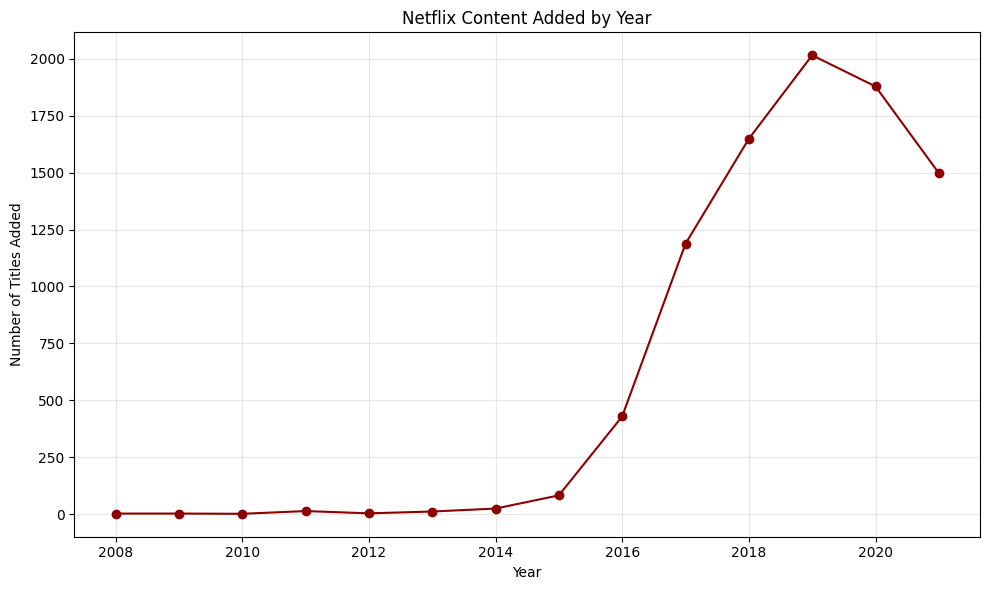

In [ ]:
plt.figure(figsize=(10,6))
content_by_year.plot(kind='line', marker='o', color='darkred')
plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

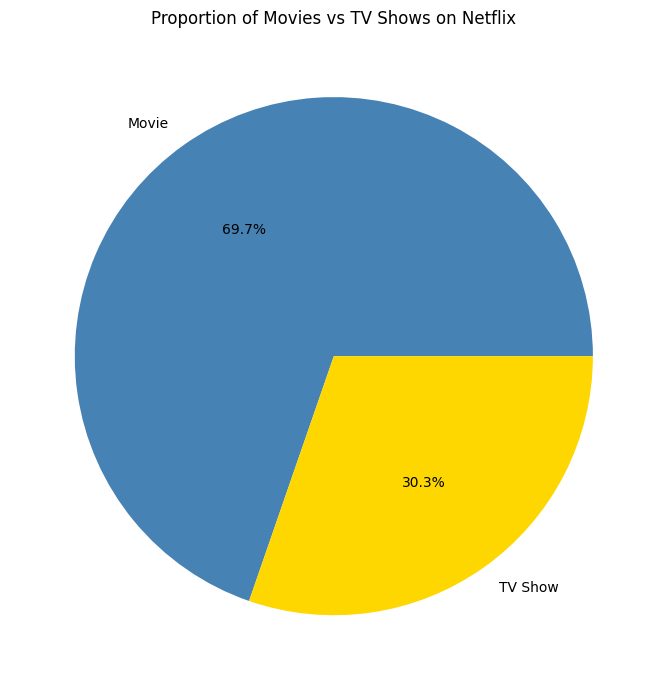

In [ ]:
plt.figure(figsize=(7,7))
plt.pie(type_distribution, labels=type_distribution.index, autopct='%1.1f%%', colors=['steelblue','gold'])
plt.title('Proportion of Movies vs TV Shows on Netflix')
plt.tight_layout()
plt.show()

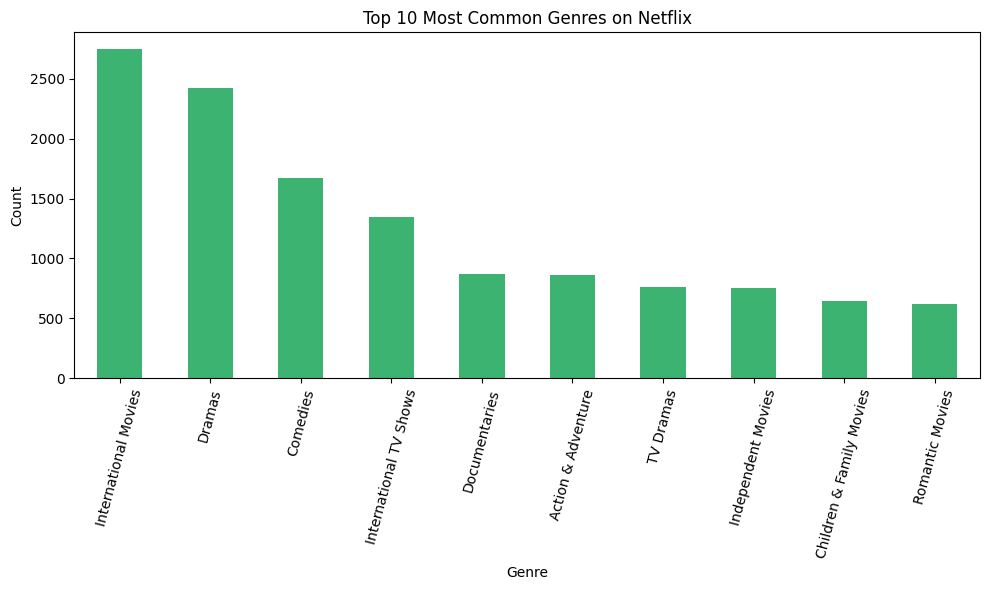

In [ ]:
plt.figure(figsize=(10,6))
top_genres.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

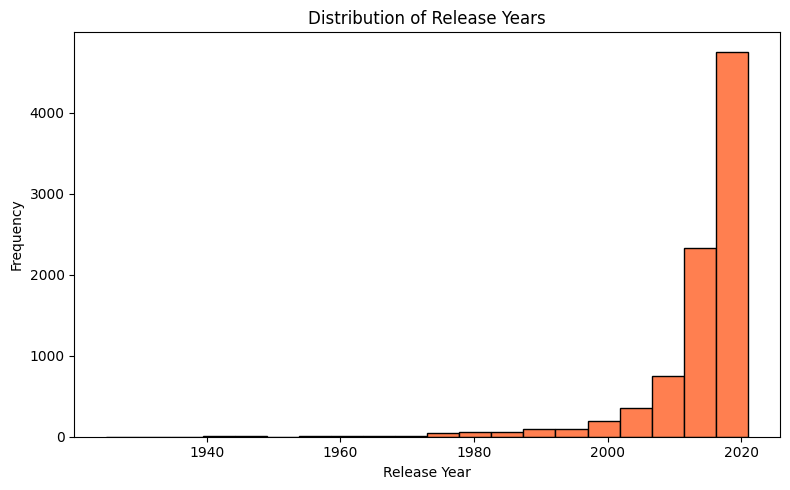

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['release_year'], bins=20, color='coral', edgecolor='black')
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

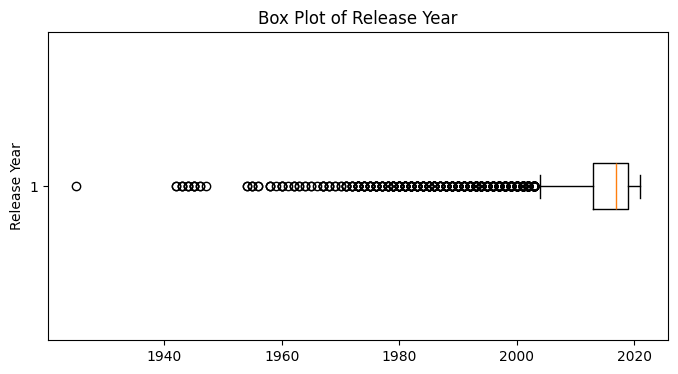

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(df['release_year'], vert = False)
plt.title("Box Plot of Release Year")
plt.ylabel("Release Year")
plt.show()

# **DATASET KEY INSIGHTS **

---

* Movies dominate Netflix's catalog, Movies make up 69.6% of all titles (6,131) compared to TV Shows at 30.4% (2,676)

  This shows thta Movies make up the majority of Netflix's content, while TV shows represent a smaller share. this indicates that Netflix focuses more on offering movies than series (See: Movies vs TV Shows bar chart and pie chart)

* Content additions grew explosively between 2016 and 2019, then declined

  The number of titles added per year stayed under 100 until 2015, then surged to 429 (2016), 1,188 (2017), 1,649 (2018), and peaked at 2,016 in 2019 - before dropping to 1,879 (2020) and 1,498 (2021). This pattern likely reflects Netflix's rapid content expansion ot its content library during the years. (See: Content Added by Year line chart)

* The United States is the leading content production country

  The US produced 2,818 titles - nearly three times more than the next country, India (972), and far ahead of the UK (419). This shows that the United State contributes the largest number of titles on Netflix. (See: Top 10 Content-Producing Countries analysis)

* Mature-audience content (TV-MA) is the most common rating

  TV-MA leads with 3,207 titles, followed by TV-14 (2,160) - together these two ratings account for the majority of the catalog. This indicates Netflix's content library leans toward adult and teen/young-adult audiences rather than family-friendly content. (See: Most Common Ratings analysis)

* International and dramatic content define Netflix's genre identity

  "International Movies" is the single most common genre tag (2,752), followed by Dramas (2,427) and Comedies (1,674). This reflects Netflix's global content strategy, sourcing and promoting content across regions rather than concentrating on a narrow set of genres. (See: Top Genres bar chart)

# **NETFLIX DATASET ANALYSIS SUMMARY REPORT**

---
  
The Netflix dataset contains information on 8,807 movies and TV shows available on Netflix. The dataset includes details such as show ID, title, content type, director, cast, country, date added, release year, rating, duration, genre, and description. The objective of this analysis was to clean the dataset, perform exploratory data analysis (EDA), create visualizations, and generate meaningful insights.

During the data cleaning process, missing values were identified in the director, cast, country, rating, duration, and date_added columns. Missing values in the director, cast, country, rating, and duration columns were filled with "Unknown" to preserve as many records as possible, while rows with missing date_added values were removed because the date was essential for time-based analysis. Duplicate records were checked, and no duplicate rows were found. The date_added column was converted to a datetime format, column names were standardized to lowercase, and unnecessary spaces were removed from text columns to ensure consistency.

The exploratory data analysis revealed several important findings. Movies make up a larger proportion of Netflix's catalog than TV shows. The number of titles added to Netflix increased significantly over the years, with the highest growth occurring around 2019-2020. The United States was identified as the leading producer of Netflix content, followed by countries such as India and the United Kingdom. The TV-MA rating was the most common content rating, indicating that much of Netflix's catalog is intended for mature audiences. Drama-related genres were also found to be the most common categories on the platform.

The visualizations, including bar charts, pie charts, line charts, histograms, and box plots, clearly illustrated these trends and patterns, making it easier to interpret the data and communicate findings effectively.

Overall, this project demonstrated the importance of data cleaning and
exploratory data analysis in transforming raw data into meaningful insights. The cleaned dataset is now reliable for further analysis and can support better understanding of Netflix's content distribution, production trends, and audience preferences.